# Regression: Simple, Multiple, Polynomial; Evaluation, Overfitting, and Regularization

### Table of contents
0. [Introduction](#0.-Introduction)
1. [The dataset: California Housing](#1.-The-dataset:-California-Housing)
2. [A quick look at the data](#2.-A-quick-look-at-the-data)
3. [Train/test split](#3.-Train/test-split)
4. [Preparing the data: fit on train, transform test](#4.-Preparing-the-data:-fit-on-train,-transform-test)
5. [Simple Linear Regression](#5.-Simple-Linear-Regression)
6. [Multiple Linear Regression](#6.-Multiple-Linear-Regression)
7. [Polynomial Regression](#7.-Polynomial-Regression)
8. [Evaluation metrics: MAE, MSE/RMSE, R²](#8.-Evaluation-metrics:-MAE,-MSE/RMSE,-R²)
9. [Overfitting and underfitting](#9.-Overfitting-and-underfitting)
10. [Learning curves](#10.-Learning-curves)
11. [Regularization: Ridge, Lasso, ElasticNet](#11.-Regularization:-Ridge,-Lasso,-ElasticNet)
12. [Cross-validation](#12.-Cross-validation)
13. [Summary](#13.-Summary)
14. [Exercises](#14.-Exercises)

## 0. Introduction

Supervised learning splits into two families: **classification** (predicting a category) and **regression** (predicting a continuous number). This notebook is our first time doing the second one, following the same pipeline a real project follows, in the same order:

1. Load the data.
2. Look at it before touching anything (we did this in depth in week 2; here's a richer-than-minimal recap).
3. **Split into train and test, before building any model.**
4. **Prepare the data (scaling, etc.), fitting only on train.** Preprocessing that peeks at the test set is just as much a leak as evaluating on it.
5. Build models, simplest first: **simple** regression (one feature) → **multiple** regression (many features) → **polynomial** regression (curved relationships).
6. Judge them honestly with **evaluation metrics** (MAE, RMSE, R²) computed on the held-out test set.
7. Diagnose **overfitting and underfitting**, the two ways a model goes wrong.
8. Fix them with **regularization and cross-validation**.

None of this requires you to derive or compute anything by hand. `scikit-learn` finds the best-fitting parameters for you; your job is to call the right API, respect the train/test boundary at every step (not just splitting, preprocessing too), and read the results correctly.

In [36]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pandas.plotting import scatter_matrix

from sklearn.datasets import fetch_california_housing
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet, SGDRegressor
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import train_test_split, learning_curve, cross_val_score
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

rng = np.random.default_rng(42)

plt.rcParams["figure.figsize"] = (6, 4)
plt.rcParams["axes.grid"] = True

## 1. The dataset: California Housing

Per the course's dataset standard, we use `California Housing`, a single-call, scikit-learn-loadable dataset, the same one we cleaned and explored in week 2. The task: predict the median house value of a district from things like the median income, house age, and average number of rooms in that district.

In [37]:
housing = fetch_california_housing(as_frame=True)
df = housing.frame
df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


Each row is one California district (a small geographic area, not a single house). The target column is `MedHouseVal`, in units of $100,000s.

## 2. A quick look at the data

Week 2's `04_eda_data_cleaning.ipynb` walked through this exact dataset in real depth: shape, dtypes, missing values, duplicates, outliers, scaling. We won't repeat all of that, but skipping straight to modeling would teach the wrong habit. So: a proper (if faster) pass over that same checklist, then we move on.

### 2.1 Shape, dtypes, and missing values

In [38]:
print("Shape:", df.shape)
df.info()

Shape: (20640, 9)
<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   MedInc       20640 non-null  float64
 1   HouseAge     20640 non-null  float64
 2   AveRooms     20640 non-null  float64
 3   AveBedrms    20640 non-null  float64
 4   Population   20640 non-null  float64
 5   AveOccup     20640 non-null  float64
 6   Latitude     20640 non-null  float64
 7   Longitude    20640 non-null  float64
 8   MedHouseVal  20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB


In [39]:
df.isna().sum().sum()

np.int64(0)

Zero missing values, this particular dataset ships pre-cleaned. That won't always be true, which is exactly why week 2 spent a whole notebook on it, but here we can confirm it and move on instead of manufacturing a problem that isn't there.

### 2.2 Distribution of the target

Before predicting `MedHouseVal`, it's worth seeing its spread:

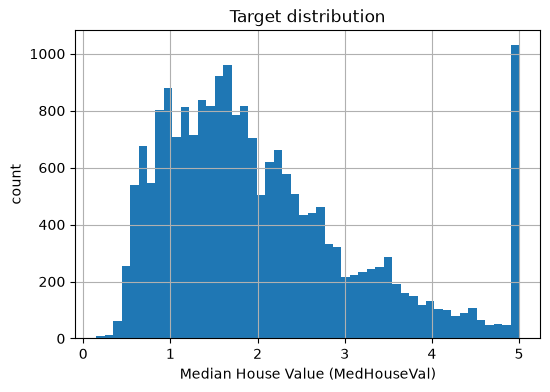

In [40]:
df["MedHouseVal"].hist(bins=50)
plt.xlabel("Median House Value (MedHouseVal)")
plt.ylabel("count")
plt.title("Target distribution")
plt.show()

That spike at the right edge is a capped value, the dataset tops out `MedHouseVal` at 5 ($500,000). Week 2 covers this in more detail; we'll leave it as-is here, but keep it in mind, it'll explain a pattern we see again in section 8.

### 2.3 Which features correlate with the target?

A quick correlation check tells us, roughly, what to expect before we build anything:

In [41]:
corr_matrix = df.corr(numeric_only=True)
corr_matrix["MedHouseVal"].sort_values(ascending=False)

MedHouseVal    1.000000
MedInc         0.688075
AveRooms       0.151948
HouseAge       0.105623
AveOccup      -0.023737
Population    -0.024650
Longitude     -0.045967
AveBedrms     -0.046701
Latitude      -0.144160
Name: MedHouseVal, dtype: float64

`MedInc` stands out well above the rest, our first model will use exactly that feature.

### 2.4 A closer look: scatter matrix of the top features

Numbers alone can hide a lot. A scatter matrix plots every pair of a few chosen features against each other; the diagonal shows each feature's own distribution:

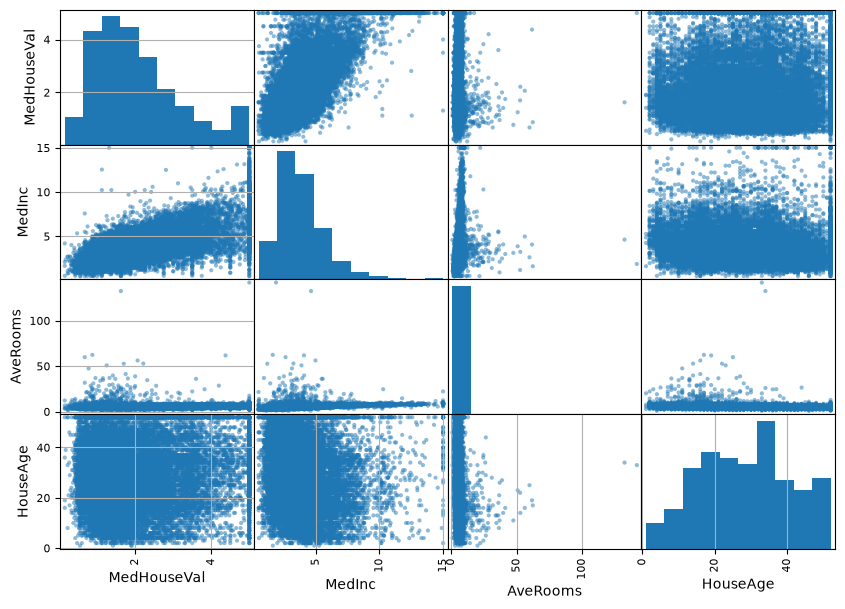

In [42]:
attributes = ["MedHouseVal", "MedInc", "AveRooms", "HouseAge"]
scatter_matrix(df[attributes], figsize=(10, 7))
plt.show()

The `MedHouseVal` vs. `MedInc` panel confirms the strong, fairly linear relationship we found in the correlation table, and you can also spot that same capped ceiling at `MedHouseVal = 5` as a flat band of points.

### 2.5 Geographic scatter: latitude/longitude colored by price

This dataset has a spatial dimension too. Plotting every district by its coordinates, colored by price, should look familiar from week 2:

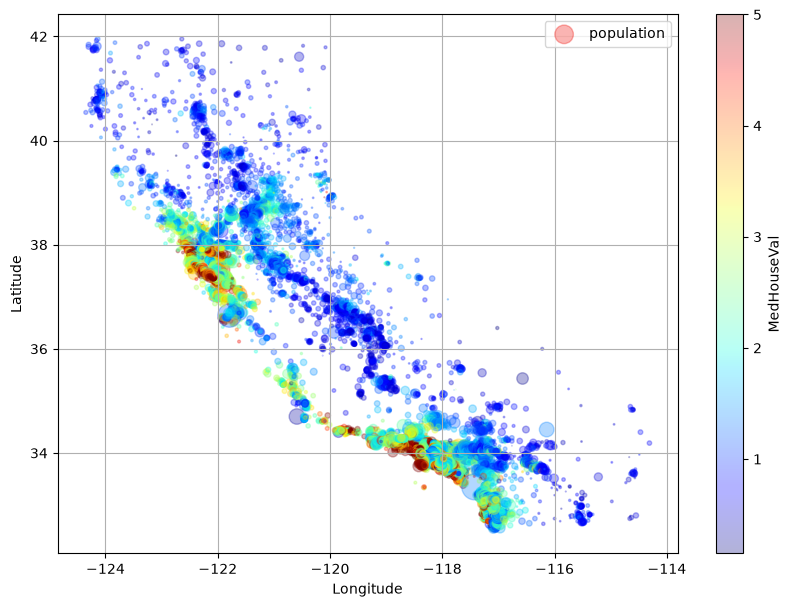

In [43]:
df.plot(kind="scatter", x="Longitude", y="Latitude", grid=True,
        alpha=0.3, s=df["Population"] / 100, label="population",
        c="MedHouseVal", cmap="jet", colorbar=True,
        legend=True, figsize=(10, 7))
plt.show()

Location matters: price clearly clusters along the coast. `Latitude` and `Longitude` are in our feature list for multiple regression (section 6), this is a preview of why they carry real signal, even though "coordinates predict price" isn't an obvious relationship on paper.

## 3. Train/test split

If we evaluate a model on the same data it was trained on, we're grading an exam using the answer key the student already saw. To measure genuine performance, we hold out a test set the model never sees during training, and we do this **before** building any model, not as an afterthought once we already like what we see.

We split once, here, on the full feature set. Every California Housing model in this notebook (simple, multiple, or otherwise) reuses this same `X_train` / `X_test` split, just with different columns selected, so results stay comparable across sections.

In [44]:
features = ["MedInc", "HouseAge", "AveRooms", "AveBedrms",
            "Population", "AveOccup", "Latitude", "Longitude"]

X = df[features]
y = df["MedHouseVal"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Train size:", X_train.shape[0])
print("Test size: ", X_test.shape[0])

Train size: 16512
Test size:  4128


## 4. Preparing the data: fit on train, transform test

One more discipline before modeling: any preprocessing step that *learns* something from the data, like a scaler's mean and standard deviation, must learn it from the **training set only**. If it also saw the test set while learning that mean, information about the test set would leak into training, quietly, before a single model is even fit, and our later evaluation would stop being honest.

`StandardScaler` is the standard tool for this: it centers each feature on 0 with a standard deviation of 1.

In [45]:
scaler = StandardScaler()
scaler.fit(X_train)   # learns mean/std from TRAIN only

X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)   # test is only ever transformed, never fit

pd.DataFrame(X_train_scaled, columns=features).describe().loc[["mean", "std"]].round(3)

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
mean,-0.0,-0.0,0.0,-0.0,0.0,0.0,0.0,0.0
std,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0


Every training feature now has mean ≈ 0 and standard deviation ≈ 1, as expected. The test set was transformed using that *same* train-derived mean and std, so it won't be perfectly centered, and that's the point:

In [46]:
print("Test set mean after scaling (not exactly 0 — as expected):")
pd.DataFrame(X_test_scaled, columns=features).mean().round(3)

Test set mean after scaling (not exactly 0 — as expected):


MedInc       -0.026
HouseAge      0.012
AveRooms     -0.013
AveBedrms    -0.000
Population   -0.004
AveOccup     -0.011
Latitude     -0.026
Longitude     0.031
dtype: float64

That small offset is an honest preview of how genuinely new data behaves once it passes through a pipeline fit on training data. If we'd instead fit the scaler on the full dataset (train + test together), the test set would look artificially well-behaved, a subtle form of the same leakage that skipping `train_test_split` entirely would cause.

This `fit` on train / `transform` on test pattern is exactly what a scikit-learn `Pipeline` does for you automatically, which is why we wrap `StandardScaler` inside `make_pipeline(...)` throughout the rest of this notebook (sections 5.3 and 11) instead of repeating this by hand. `pipe.fit(X_train, y_train)` fits every preprocessing step on train; `pipe.predict(X_test)` and `pipe.score(X_test, y_test)` only ever call `.transform()` on test.

## 5. Simple Linear Regression

### 5.1 One feature: `MedInc` → `MedHouseVal`

Let's start with the simplest possible case: one input feature, `MedInc` (median income), predicting one output, `MedHouseVal`. We already saw in section 2.3 that it's the most correlated feature, a good candidate for a straight-line model:

```
ŷ = w·x + b
```

Fitting this line means finding the `w` and `b` that minimize the mean squared error between `ŷ` and the real `y`, on the **training set only**. That optimization is exactly what `LinearRegression.fit()` does for you. (Plain `LinearRegression` doesn't need scaled inputs, unlike `SGDRegressor` and the regularized models below, so we use the original, unscaled `X_train` here.)

In [47]:
X_train_simple = X_train[["MedInc"]]   # note the double brackets, more on this below
X_test_simple = X_test[["MedInc"]]

simple_model = LinearRegression()
simple_model.fit(X_train_simple, y_train)

print("w (coef_):      ", simple_model.coef_)
print("b (intercept_):  ", simple_model.intercept_)

w (coef_):       [0.41933849]
b (intercept_):   0.4445972916907879


So `simple_model.coef_[0]` is the slope: each extra unit of `MedInc` (which is in units of $10,000s) is associated with roughly that much increase in `MedHouseVal`. Let's plot the fitted line on top of the **training** data:

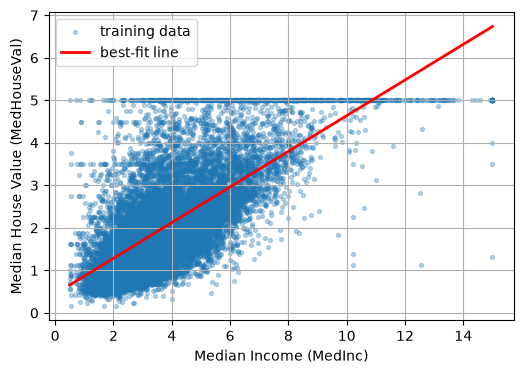

In [48]:
x_line = pd.DataFrame({"MedInc": np.linspace(X_train_simple["MedInc"].min(), X_train_simple["MedInc"].max(), 100)})
y_line = simple_model.predict(x_line)

plt.scatter(X_train_simple, y_train, s=8, alpha=0.3, label="training data")
plt.plot(x_line, y_line, color="red", linewidth=2, label="best-fit line")
plt.xlabel("Median Income (MedInc)")
plt.ylabel("Median House Value (MedHouseVal)")
plt.legend()
plt.show()

We can now predict for a new, unseen income value:

In [49]:
new_income = pd.DataFrame({"MedInc": [8.0]})   # $80,000 median income, still 2D!
predicted_value = simple_model.predict(new_income)
print(f"Predicted median house value: {predicted_value[0]:.2f} (x $100,000)")

Predicted median house value: 3.80 (x $100,000)


And, critically, we check performance on the **test set**, data the model never saw while fitting:

In [50]:
simple_model.score(X_test_simple, y_test)

0.45885918903846656

That's the R² of the model on genuinely new data, we'll unpack exactly what R² means in section 8. For now, treat it as "how good is the fit," from 0 (useless) towards 1 (perfect).

### 5.2 The shape gotcha

`scikit-learn` always expects `X` with shape `(n_samples, n_features)`, a 2D array, even when there's only one feature. Compare:

In [51]:
print("X_train['MedInc'] shape:   ", X_train["MedInc"].shape)     # 1D — (n,)
print("X_train[['MedInc']] shape: ", X_train[["MedInc"]].shape)   # 2D — (n, 1), what we want

X_train['MedInc'] shape:    (16512,)
X_train[['MedInc']] shape:  (16512, 1)


In [52]:
try:
    LinearRegression().fit(X_train["MedInc"], y_train)   # single brackets: 1D — will raise
except ValueError as e:
    print("ValueError:", e)

ValueError: Expected a 2-dimensional container but got <class 'pandas.Series'> instead. Pass a DataFrame containing a single row (i.e. single sample) or a single column (i.e. single feature) instead.


This is exactly the same "shape gotcha" you saw with NumPy in week 2: `(n,)`, `(n, 1)`, and `(1, n)` are different shapes, and scikit-learn is strict about which one it wants.

### 5.3 How the weights are found

`simple_model.fit()` searched for the `w` and `b` that minimize the cost (mean squared error) on the training set. Concretely, if we hold `b` fixed at its optimal value and vary `w`, the cost traces a bowl-shaped curve, and the bottom of that bowl is exactly the `w` scikit-learn returned:

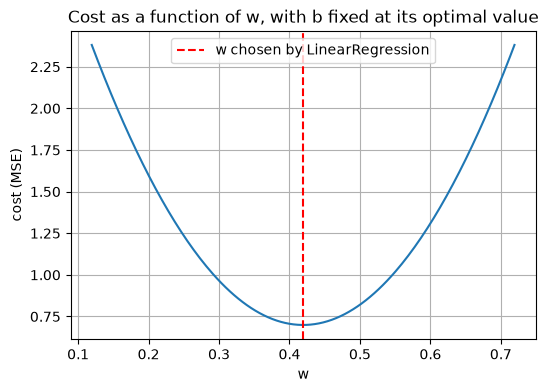

In [53]:
def cost(w, b):
    pred = w * X_train_simple["MedInc"].values + b
    return np.mean((y_train.values - pred) ** 2)

w_best = simple_model.coef_[0]
w_range = np.linspace(w_best - 0.3, w_best + 0.3, 200)
costs = [cost(w, simple_model.intercept_) for w in w_range]

plt.plot(w_range, costs)
plt.axvline(w_best, color="red", linestyle="--", label="w chosen by LinearRegression")
plt.xlabel("w")
plt.ylabel("cost (MSE)")
plt.title("Cost as a function of w, with b fixed at its optimal value")
plt.legend()
plt.show()

`LinearRegression` finds the bottom of this bowl using a direct formula (the **Normal Equation**), computed once, no searching involved. An alternative is `SGDRegressor`, which reaches the same bottom by taking repeated small steps downhill (**Gradient Descent**), the standard choice when the data is too large for the direct formula to be practical. Let's confirm both routes land in the same place. `SGDRegressor` needs scaled features to take stable steps, so we wrap it in a pipeline (which, per section 4, fits the scaler on train and only transforms test):

In [54]:
sgd_model = make_pipeline(
    StandardScaler(),
    SGDRegressor(max_iter=1000, tol=1e-3, random_state=42),
)
sgd_model.fit(X_train_simple, y_train)

print(f"LinearRegression (Normal Equation) test R²: {simple_model.score(X_test_simple, y_test):.4f}")
print(f"SGDRegressor (Gradient Descent)     test R²: {sgd_model.score(X_test_simple, y_test):.4f}")

LinearRegression (Normal Equation) test R²: 0.4589
SGDRegressor (Gradient Descent)     test R²: 0.4588


Two different computation strategies, essentially the same answer. You will almost always reach for `LinearRegression`, `Ridge`, or `Lasso` directly; `SGDRegressor` matters once datasets get too large for the direct formula.

## 6. Multiple Linear Regression

Realistically, income alone won't explain house prices well. Let's use every numeric feature at once, same training set, same test set, just more columns. The model and the API are **identical**.

In [55]:
multi_model = LinearRegression()
multi_model.fit(X_train, y_train)

coefs = pd.Series(multi_model.coef_, index=features).sort_values(key=abs, ascending=False)
coefs

AveBedrms     0.783145
MedInc        0.448675
Longitude    -0.433708
Latitude     -0.419792
AveRooms     -0.123323
HouseAge      0.009724
AveOccup     -0.003526
Population   -0.000002
dtype: float64

Reading a coefficient: "holding every other feature constant, one unit more of this feature is associated with this much change in `ŷ`." Be careful comparing the *size* of coefficients across features directly, they're on very different scales (`Population` is in the thousands, `AveRooms` is a small number), so a coefficient looking "bigger" doesn't automatically mean that feature matters more.

Let's check whether using all features actually improved the fit over the single-feature model, comparing both on the **same held-out test set**:

In [56]:
y_pred_simple = simple_model.predict(X_test_simple)
y_pred_multi = multi_model.predict(X_test)

print("Simple regression (MedInc only)  test R²:", r2_score(y_test, y_pred_simple))
print("Multiple regression (all features) test R²:", r2_score(y_test, y_pred_multi))

Simple regression (MedInc only)  test R²: 0.45885918903846656
Multiple regression (all features) test R²: 0.5757877060324512


## 7. Polynomial Regression

### 7.1 When a straight line isn't enough

For this section we switch to a small **synthetic** dataset with a known curved relationship. That's a deliberate choice: it makes the effect of `degree` easy to see on a plot, which noisy real-world data would obscure. We'll come back to disciplined train/test evaluation for it in section 9.

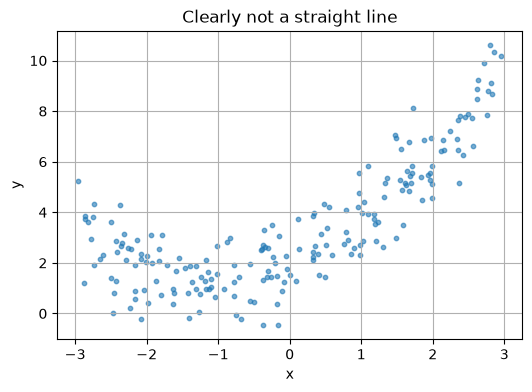

In [57]:
m = 200
X_syn = 6 * rng.random((m, 1)) - 3          # x in [-3, 3]
y_syn = 0.5 * X_syn ** 2 + X_syn + 2 + rng.standard_normal((m, 1))

plt.scatter(X_syn, y_syn, s=10, alpha=0.6)
plt.xlabel("x")
plt.ylabel("y")
plt.title("Clearly not a straight line")
plt.show()

If we force a plain linear regression onto this, it underperforms no matter how much data we add, a straight line simply cannot represent a curve:

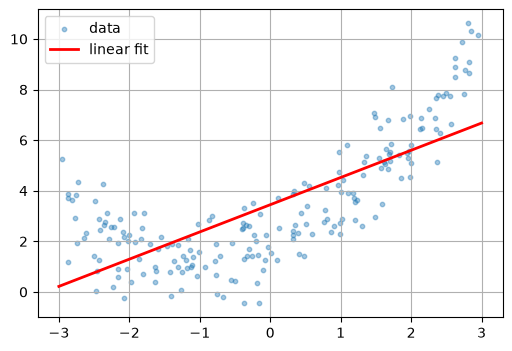

In [58]:
x_grid = np.linspace(-3, 3, 100).reshape(-1, 1)

linear_model = LinearRegression()
linear_model.fit(X_syn, y_syn)
y_grid_linear = linear_model.predict(x_grid)

plt.scatter(X_syn, y_syn, s=10, alpha=0.4, label="data")
plt.plot(x_grid, y_grid_linear, color="red", linewidth=2, label="linear fit")
plt.legend()
plt.show()

### 7.2 The trick: engineer the features, not the algorithm

`PolynomialFeatures` builds `x`, `x²`, `x³`, ... as new columns. We then run the exact same `LinearRegression` on top of these expanded features, it's still a linear regression, just with a richer set of inputs.

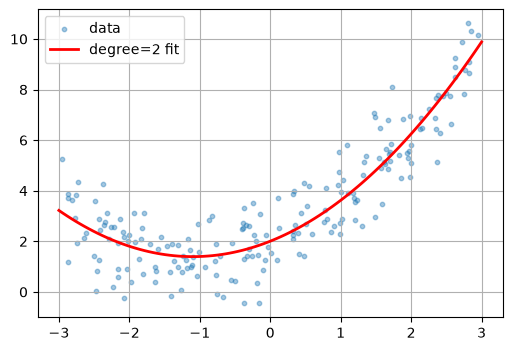

In [59]:
poly_model = make_pipeline(
    PolynomialFeatures(degree=2, include_bias=False),
    LinearRegression(),
)
poly_model.fit(X_syn, y_syn)

y_grid_poly = poly_model.predict(x_grid)

plt.scatter(X_syn, y_syn, s=10, alpha=0.4, label="data")
plt.plot(x_grid, y_grid_poly, color="red", linewidth=2, label="degree=2 fit")
plt.legend()
plt.show()

Much better. `degree` controls how much curvature the model is allowed to have. Let's compare a few degrees on the same plot:

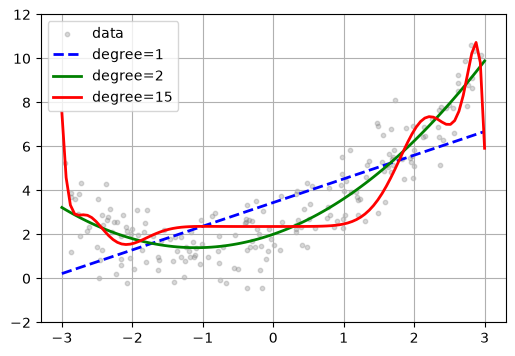

In [60]:
plt.scatter(X_syn, y_syn, s=10, alpha=0.3, label="data", color="gray")

for degree, style in [(1, "b--"), (2, "g-"), (15, "r-")]:
    pipe = make_pipeline(PolynomialFeatures(degree=degree, include_bias=False), LinearRegression())
    pipe.fit(X_syn, y_syn)
    plt.plot(x_grid, pipe.predict(x_grid), style, linewidth=2, label=f"degree={degree}")

plt.ylim(-2, 12)
plt.legend()
plt.show()

Notice `degree=15` snakes through the noise instead of the underlying trend. This is our first hands-on look at a model that is *too* flexible, exactly the topic of section 9. But first, we need a rigorous way to measure "how good" at all.

## 8. Evaluation metrics: MAE, MSE/RMSE, R²

Every metric below is just a different way of summarizing the **residuals**, `y_true - y_pred`, into one number. We'll reuse the multiple regression model's predictions on the test set from section 6.

In [61]:
residuals = y_test - y_pred_multi
residuals.head()

20046   -0.242123
3024    -1.306017
15663    2.290351
20484   -0.652926
9814     0.175343
Name: MedHouseVal, dtype: float64

### 8.1 MAE (Mean Absolute Error)

The average absolute size of the error, in the same units as `y`:

In [62]:
mae_manual = np.mean(np.abs(residuals))
mae_sklearn = mean_absolute_error(y_test, y_pred_multi)

print(f"MAE (manual):  {mae_manual:.4f}")
print(f"MAE (sklearn): {mae_sklearn:.4f}")

MAE (manual):  0.5332
MAE (sklearn): 0.5332


### 8.2 MSE and RMSE

`MSE` is what the model actually minimizes internally, but its units are squared (hard to interpret), so we usually report `RMSE`, its square root, back in the original units of `y`. Squaring means large errors are penalized disproportionately more than small ones.

In [63]:
mse_manual = np.mean(residuals ** 2)
rmse_manual = np.sqrt(mse_manual)

mse_sklearn = mean_squared_error(y_test, y_pred_multi)
rmse_sklearn = mse_sklearn ** 0.5

print(f"MSE:  {mse_manual:.4f} (manual)  |  {mse_sklearn:.4f} (sklearn)")
print(f"RMSE: {rmse_manual:.4f} (manual)  |  {rmse_sklearn:.4f} (sklearn)")

MSE:  0.5559 (manual)  |  0.5559 (sklearn)
RMSE: 0.7456 (manual)  |  0.7456 (sklearn)


### 8.3 R² (coefficient of determination)

`R²` compares our model's error to the error of the simplest possible baseline: always predicting the mean of `y`.

In [64]:
ss_res = np.sum((y_test - y_pred_multi) ** 2)
ss_tot = np.sum((y_test - y_test.mean()) ** 2)
r2_manual = 1 - ss_res / ss_tot

r2_sklearn = r2_score(y_test, y_pred_multi)
r2_via_score = multi_model.score(X_test, y_test)

print(f"R² (manual):      {r2_manual:.4f}")
print(f"R² (sklearn):     {r2_sklearn:.4f}")
print(f"R² (model.score): {r2_via_score:.4f}")

R² (manual):      0.5758
R² (sklearn):     0.5758
R² (model.score): 0.5758


### 8.4 Always compare train vs. test

In [65]:
y_pred_multi_train = multi_model.predict(X_train)

print("           Train      Test")
print(f"MAE   {mean_absolute_error(y_train, y_pred_multi_train):>10.4f} {mean_absolute_error(y_test, y_pred_multi):>10.4f}")
print(f"RMSE  {mean_squared_error(y_train, y_pred_multi_train) ** 0.5:>10.4f} {mean_squared_error(y_test, y_pred_multi) ** 0.5:>10.4f}")
print(f"R²    {r2_score(y_train, y_pred_multi_train):>10.4f} {r2_score(y_test, y_pred_multi):>10.4f}")

           Train      Test
MAE       0.5286     0.5332
RMSE      0.7197     0.7456
R²        0.6126     0.5758


Train and test scores are close here, this particular model (plain linear regression, 8 features) is not complex enough to overfit this much data. That won't stay true once we let the model get more flexible, as we'll see next.

### 8.5 A look at the residuals themselves

A single number can hide a lot. Plotting predictions against their residuals often reveals patterns that MAE/RMSE/R² alone can't show:

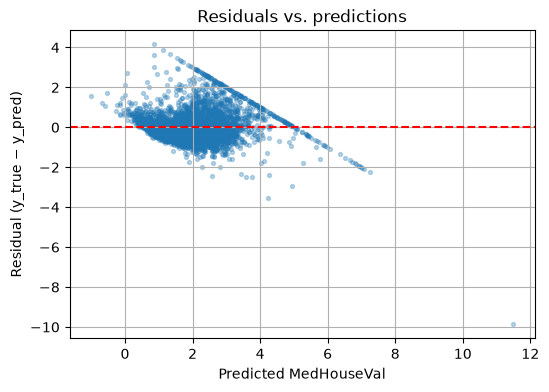

In [66]:
plt.scatter(y_pred_multi, residuals, s=8, alpha=0.3)
plt.axhline(0, color="red", linestyle="--")
plt.xlabel("Predicted MedHouseVal")
plt.ylabel("Residual (y_true − y_pred)")
plt.title("Residuals vs. predictions")
plt.show()

Ideally residuals scatter randomly around zero with no shape. Here there's a visible diagonal streak: those are the districts capped at `MedHouseVal = 5` from section 2.2, the model predicts a range of values for them, but the true value can't go above 5, so the residual is forced negative in exact proportion to the prediction. A metric alone wouldn't have told us *why* the errors look the way they do; the plot does.

## 9. Overfitting and underfitting

Let's bring back the synthetic curved dataset from section 7, small and noisy, so it's easy to push a model into overfitting. Same discipline as before: split before fitting.

In [67]:
m_small = 60
X_small = 6 * rng.random((m_small, 1)) - 3
y_small = 0.5 * X_small ** 2 + X_small + 2 + rng.standard_normal((m_small, 1))

Xs_train, Xs_test, ys_train, ys_test = train_test_split(X_small, y_small, test_size=0.3, random_state=0)

In [68]:
results = []
for degree in [1, 2, 15]:
    pipe = make_pipeline(PolynomialFeatures(degree=degree, include_bias=False), LinearRegression())
    pipe.fit(Xs_train, ys_train)
    train_rmse = mean_squared_error(ys_train, pipe.predict(Xs_train)) ** 0.5
    test_rmse = mean_squared_error(ys_test, pipe.predict(Xs_test)) ** 0.5
    results.append({"degree": degree, "train_rmse": train_rmse, "test_rmse": test_rmse})

pd.DataFrame(results)

,degree,train_rmse,test_rmse
0,1,1.623324,1.644311
1,2,1.090478,1.141687
2,15,1.237884,1.412361


Read this table like a diagnosis:

- **degree=1**: train and test error both high and close together, **underfitting**.
- **degree=2**: train and test error both low and close together, **good fit**.
- **degree=15**: train error near zero, test error much higher, **overfitting**.

This gap between train and test error, not the train error alone, is the signal to watch for.

## 10. Learning curves

`learning_curve` automates a very useful experiment: retrain the model on growing subsets of the training data, and track train vs. validation error at each size. `scikit-learn` handles the cross-validation splitting internally.

In [69]:
def plot_learning_curve(estimator, X, y, title):
    train_sizes, train_scores, valid_scores = learning_curve(
        estimator, X, y, train_sizes=np.linspace(0.1, 1.0, 20), cv=5,
        scoring="neg_root_mean_squared_error",
    )
    train_errors = -train_scores.mean(axis=1)
    valid_errors = -valid_scores.mean(axis=1)

    plt.plot(train_sizes, train_errors, "o-", label="train")
    plt.plot(train_sizes, valid_errors, "o-", label="validation")
    plt.xlabel("Training set size")
    plt.ylabel("RMSE")
    plt.title(title)
    plt.legend()
    plt.show()

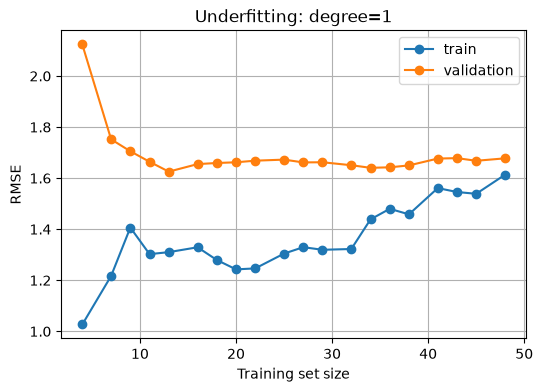

In [70]:
plot_learning_curve(LinearRegression(), X_small, y_small, "Underfitting: degree=1")

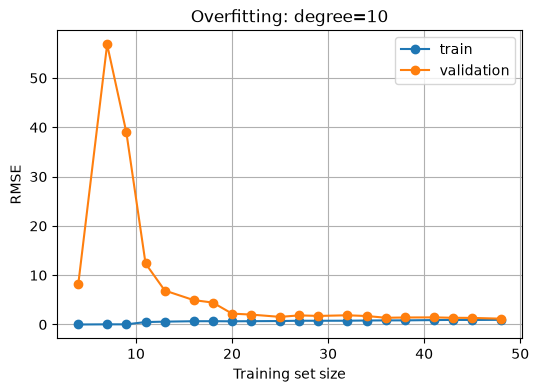

In [71]:
degree10_pipe = make_pipeline(PolynomialFeatures(degree=10, include_bias=False), LinearRegression())
plot_learning_curve(degree10_pipe, X_small, y_small, "Overfitting: degree=10")

In the underfitting curve, both lines plateau at a high, similar error, more data wouldn't help much; the model itself is too simple. In the overfitting curve, there's a persistent gap between train and validation error, the classic overfitting signature.

## 11. Regularization: Ridge, Lasso, ElasticNet

Regularization penalizes large coefficients, discouraging the model from chasing noise. Because the penalty depends on coefficient *size*, features must be scaled first (section 4's discipline again), otherwise a feature's scale, not its actual importance, determines how much it gets penalized.

In [72]:
def make_reg_pipeline(model_cls, alpha, degree=10, **kwargs):
    return make_pipeline(
        PolynomialFeatures(degree=degree, include_bias=False),
        StandardScaler(),
        model_cls(alpha=alpha, **kwargs),
    )

print("alpha      train_rmse   test_rmse")
for alpha in [0.0001, 0.01, 1.0, 10.0]:
    pipe = make_reg_pipeline(Ridge, alpha)
    pipe.fit(Xs_train, ys_train.ravel())
    train_rmse = mean_squared_error(ys_train, pipe.predict(Xs_train)) ** 0.5
    test_rmse = mean_squared_error(ys_test, pipe.predict(Xs_test)) ** 0.5
    print(f"{alpha:<10} {train_rmse:<12.4f} {test_rmse:<12.4f}")

alpha      train_rmse   test_rmse
0.0001     0.8765       1.7966      
0.01       0.9634       1.2129      
1.0        1.0401       1.1187      
10.0       1.1967       1.3157      


As `alpha` grows, the model is pushed towards simplicity: train error rises a bit, but test error improves, up to a point. Seeing the actual fitted curves makes this more concrete than the table alone:

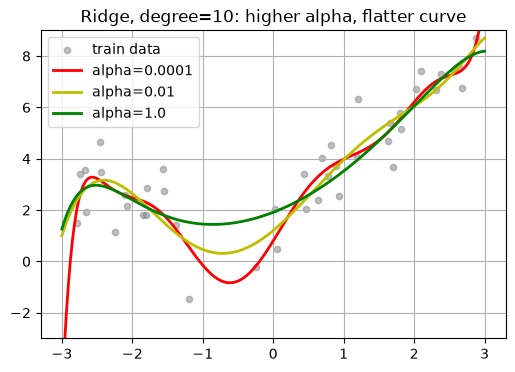

In [73]:
x_grid_small = np.linspace(-3, 3, 200).reshape(-1, 1)

plt.scatter(Xs_train, ys_train, s=20, alpha=0.5, color="gray", label="train data")
for alpha, style in [(0.0001, "r-"), (0.01, "y-"), (1.0, "g-")]:
    pipe = make_reg_pipeline(Ridge, alpha)
    pipe.fit(Xs_train, ys_train.ravel())
    plt.plot(x_grid_small, pipe.predict(x_grid_small), style, linewidth=2, label=f"alpha={alpha}")

plt.ylim(-3, 9)
plt.legend()
plt.title("Ridge, degree=10: higher alpha, flatter curve")
plt.show()

Too much `alpha` and the model becomes too constrained (underfitting again), that's the flattest, `alpha=1.0` curve above starting to miss the actual bend in the data.

`Lasso` uses the same idea with an L1 penalty, which can push coefficients to exactly zero, effectively selecting features:

In [74]:
lasso_pipe = make_reg_pipeline(Lasso, alpha=0.01, max_iter=10000)
lasso_pipe.fit(Xs_train, ys_train.ravel())

coefs = lasso_pipe.named_steps["lasso"].coef_
print(f"Total coefficients: {len(coefs)}")
print(f"Exactly zero:       {(coefs == 0).sum()}")

Total coefficients: 10
Exactly zero:       4


`ElasticNet` blends both penalties (`l1_ratio` controls the mix between L1 and L2):

In [75]:
elastic_pipe = make_reg_pipeline(ElasticNet, alpha=0.01, l1_ratio=0.5, max_iter=10000)
elastic_pipe.fit(Xs_train, ys_train.ravel())
mean_squared_error(ys_test, elastic_pipe.predict(Xs_test)) ** 0.5

1.113046186525982

## 12. Cross-validation

Picking `degree` or `alpha` by hand, based on one fixed train/test split, risks overfitting to that particular split. `cross_val_score` re-splits the training data several times and averages the result, giving a more reliable estimate for comparing settings.

In [76]:
print("degree     mean CV RMSE")
for degree in range(1, 11):
    pipe = make_pipeline(PolynomialFeatures(degree=degree, include_bias=False), LinearRegression())
    scores = cross_val_score(pipe, X_small, y_small.ravel(), cv=5, scoring="neg_root_mean_squared_error")
    print(f"{degree:<10} {-scores.mean():.4f}")

degree     mean CV RMSE
1          1.6776
2          1.0934
3          1.1851
4          1.1524
5          1.1197
6          1.1621
7          1.2068
8          1.3389
9          1.1281
10         1.1815


The `degree` with the lowest mean cross-validated RMSE is the one worth trusting, not necessarily the one with the lowest error on a single train/test split.

## 13. Summary

- The pipeline, in order: load data → look at it (week 2) → **split into train/test** → **prepare the data, fitting only on train** → build models on train → evaluate on test → diagnose → fix. Everything in this notebook follows that order; nothing was ever fit, scaled, or scored using data it shouldn't have seen yet.
- Regression predicts a **continuous number**, not a category.
- **Simple** regression: one feature, `ŷ = w·x + b`. **Multiple**: same idea, many features at once. **Polynomial**: still linear regression, just fed engineered features (`x`, `x²`, `x³`, ...).
- All three use the same `scikit-learn` API: `.fit(X, y)`, `.predict(X_new)`, `.coef_`, `.intercept_`. `X` must always be 2D.
- Preprocessing (like `StandardScaler`) must be fit on train only, then applied to test with `.transform()`. `Pipeline` does this automatically, which is why regularized and gradient-descent-based models are wrapped in one throughout this notebook.
- The best `w`/`b` sit at the bottom of a bowl-shaped cost surface. `LinearRegression` finds it directly (Normal Equation); `SGDRegressor` walks downhill to it (Gradient Descent). Same destination, different route.
- **MAE**, **RMSE**, and **R²** each summarize residuals differently: `MAE` treats all errors equally, `RMSE` penalizes large errors more, `R²` compares against a mean-only baseline and is unit-free. Plotting the residuals themselves can reveal *why* a metric looks the way it does.
- **Underfitting**: high error on both train and test, close together, the model is too simple. **Overfitting**: very low train error, high test error, the model memorized noise instead of the pattern. **Learning curves** show this gap as a function of training set size.
- **Regularization** (`Ridge`, `Lasso`, `ElasticNet`) fights overfitting by penalizing large coefficients. **Cross-validation** (`cross_val_score`) gives a more reliable way to choose hyperparameters like `degree` or `alpha` than a single train/test split.

## 14. Exercises

1. Fit a simple linear regression using `AveRooms` instead of `MedInc` (still from `X_train` / `X_test`) to predict `MedHouseVal`. Compare its test R² to the `MedInc` model's, which single feature is more predictive?
2. Using the multiple regression model, find the three features with the *smallest* absolute coefficient. Would you feel comfortable dropping them from the model just based on coefficient size? Why or why not?
3. Re-run the degree comparison plot (section 7.2) using `degree=5` instead of `degree=15`. Describe, in your own words, where it falls on the spectrum between the degree=2 and degree=15 fits.
4. Compute `MAE`, `RMSE`, and `R²` for the **simple** (single-feature, `MedInc`-only) regression model from section 5 on `X_test_simple` / `y_test`. Compare all three metrics to the multiple-feature model's scores from section 8.
5. Using the synthetic dataset from section 9, try `Lasso` with `alpha = 0.001, 0.01, 0.1, 1` (`degree=10`). For each, report how many coefficients are exactly zero. What happens as `alpha` keeps increasing?
6. Use `cross_val_score` to find the best `alpha` for `Ridge` (`degree=10`) among `[0.001, 0.01, 0.1, 1, 10]`, using `cv=5` and `scoring="neg_root_mean_squared_error"`. Which `alpha` wins, and how does it compare to the plain (non-regularized) `degree=10` model from section 9?
7. **A new dataset, start to finish.** Load `sklearn.datasets.load_diabetes(as_frame=True)`, a different (and much smaller and simpler) regression dataset: predicting disease progression one year out from 10 baseline health measurements. Repeat the core pipeline on it yourself: split into train/test, fit a `LinearRegression` using all 10 features, and report its MAE, RMSE, and R² on the test set. Is it easier or harder to predict than California housing? Back up your answer with the actual numbers, not just a guess.